# Nonlinear Sinks (Scrubbers)
The other notebook is getting rather large. Have put all functions in `modules/` under files `solvers.py`, `thresholding.py`, and `scrubbers.py`. 

This is a separate notebook because I'm not sure how successful these experiments will be!

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
%matplotlib inline

# for matrix creation and solving
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve

# stolen from workshops, six items in each
markers = ['x', 's', 'd', '+', 'o', '.']
colours = ['xkcd:salmon', 'xkcd:golden rod', 'xkcd:teal', 'xkcd:purple', 'xkcd:slate',' xkcd:silver']    

In [ ]:
from modules import scrubbers as scrub
from modules import thresholding as threshold
from modules import solvers as solver

importlib.reload(scrub)
scrub.hello_world()

'You imported the modules! :)'

The 'solver' part of `solve_diffusion()` is given below.

```py
for n in range(0, N):
        pseudo_inv = spsolve(coeff_A, U_sol[n])
        U_sol[n + 1] = pseudo_inv
```

The sink term has been absorbed into our coefficient matrix via the constant $C_2 = \Delta t k$. Currently, $k = k(x)$ is piecewise defined to be $k_s$ or $0$, depending on if $x$ is within the 'scrubber interval'.

If $k = k(x, t)$ then we need to redefine the coefficient matrix for each step. That can be easily done with `add_scrubbers()`, i.e.

```py
for n in range(0, N):
        coeff_A_on_t = add_scrubbers(coeff_A, ..., ..., k_s = time_dependent_strength, ...)
        pseudo_inv = spsolve(coeff_A, U_sol[n])
        U_sol[n + 1] = pseudo_inv
```

where `coeff_A` is the *original* coefficient matrix (without any scrubbers).

The first experiment (below) looks to mimic a saturation effect by setting $k_s = \tfrac{k_s}{t}$. As $t$ increases, the strength of the scrubber decreases. In this setting we might have a system that conserves the total amount of gas in the room (at least for a much longer time).

In [66]:
# Note the arguments have changed since we need to be able to use add_scrubbers()
# inside the function now. 
# ... There is maybe a cleaner way of doing it, but this works well enough.

def solve_diffusion_2(xs, ts, coeff_A, k_s, scrub_pos, start_time = 0.01, analytic_truncate = int(1e4)):
    # No longer need to +1 to everything 
    M, N = len(xs), len(ts)
    dx, dt = xs[1] - xs[0], ts[1] - ts[0]

    # Modified solve_diffusion as discussed
    if (coeff_A.shape[0] != M):
        raise ValueError(f'Need dimensions of coefficient matrix and space steps to match. Have {coeff_A.shape[0]} and {M+1}.')
    
    # initialise solution matrix and set initial condition
    U_sol = np.zeros((N, M))
    U_sol[0] = solver.analytical_sol(xs, start_time, analytic_truncate)

    A_scrub = coeff_A.copy()
    for pos in scrub_pos:
        A_scrub = scrub.add_scrubbers(A_scrub, dt, dx, k_s, pos)

    # spsolve needs A to be a sparse matrix (SciPy)
    for n in range(0, N - 1):
        # Construct new coefficient matrix with updated strength
        # ... only want it to get smaller, so don't divide by anything < 1.
        # --- THIS IS THE CHALLENGE: when to start making them weak?
        if ts[n] > 0.125:
            new_strength = k_s / (8*ts[n])            
            A_scrub = coeff_A.copy()
            for pos in scrub_pos:
                A_scrub = scrub.add_scrubbers(A_scrub, dt, dx, new_strength, pos)

        pseudo_inv = spsolve(A_scrub, U_sol[n])
        U_sol[n + 1] = pseudo_inv

    return U_sol    

We can test this construction by comparing it to the old system. In particular, how is the gas conserved over long time? How does the impact of the scrubber change?

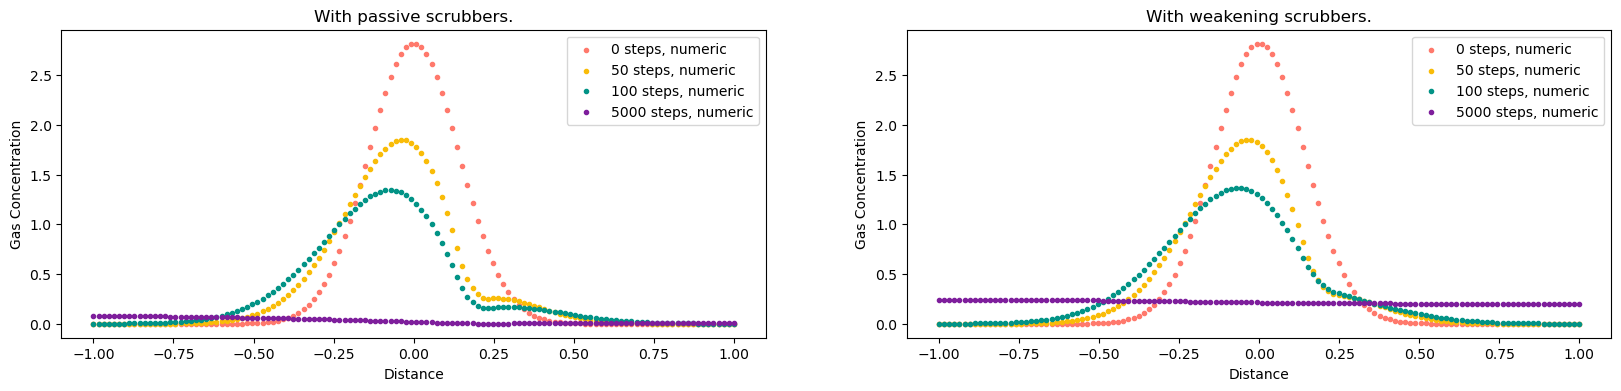

In [75]:
# Time and space constructions: use a large N
M, N, T = 250, 5000, 20
start_time = 0.01
L = 1

ts = np.linspace(start_time, T, N + 1)
xs = np.linspace(-L, L, M + 1)
dx, dt = xs[1] - xs[0], ts[1] - ts[0]

# Construct the coefficient matrix based on the diffusion coefficient
D = 0.05
C1 = (D * dt) / (dx)**2
A = solver.construct_original_A(M, C1)

# Solve and plot! Compare the two.
scrub_positions = [0.2]
k_s = 20

importlib.reload(scrub); importlib.reload(solver);
# 1. With passive scrubbers (original method)
A_scrub = A.copy()
for pos in scrub_positions:
    A_scrub = scrub.add_scrubbers(A_scrub, dt, dx, k_s, pos)

U_sol_1 = solver.solve_diffusion(N, M, A_scrub)

# 2. With time-dependent scrubbers (experiment)
U_sol_2 = solve_diffusion_2(xs, ts, A, k_s, scrub_positions)

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize = (20, 4))
times = [0, 50, 100, 5000]

# The "analytic" solution is just that with NO SCRUBBERS AT ALL. (for reference)
solver.plot_numeric(xs, U_sol_1, axes[0], times, title = "With passive scrubbers.")
solver.plot_numeric(xs, U_sol_2, axes[1], times, title = "With weakening scrubbers.")
plt.show()


You can see that the gas is definitely conserved *more* - a longer simulation would not see all of the gas dissipate into the scrubber. The scrubber is definitely weaker though.

Main issue - figuring out the best values of $D$ and $k_s$, and also the "weakening factor" of the scrubber (currently it's set as)

```py
    if ts[n] > 0.125:
            new_strength = k_s / (8*ts[n]) 
```

by trial and error.